# Method 1: Per protein enrichment score
### position-weighted mean intensity score

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
peptides = 'txt/peptides.txt' # peptide.txt file path
reference = '../references/proteomes/rat_uniprotkb_proteome_UP000002494_2026_04_13.tsv' # path to uniprot proteome .tsv reference containing protein name and protein length
peptide_filter = 6 # minumum number of peptides identified for a protein t be included in analysis
experiments = ["OPP_1", "OPP_2", "DMSO_1", "DMSO_2"] # experiment names found in Intensity column of peptides.txt i.e. 'Intensity OPP_2'

# open maquant peptides folder
peps = pd.read_csv(peptides,sep='\t')
# open uniprot proteome
uniprot = pd.read_csv(reference,sep='\t')
#filter for protein name and length
uniprot = uniprot[['Entry','Length']]
# filter crap
peps = peps[peps["Reverse"] != "+"]
peps = peps[peps["Potential contaminant"] != "+"]
# calculate middle of peptide
peps['Mid position'] = ( peps['Start position'] + peps['End position'] ) / 2
# create proteinID column name
peps = peps.rename(columns={'Leading razor protein': 'proteinID'})
uniprot = uniprot.rename(columns={'Entry': 'proteinID'})
# handle isoforms
peps["proteinID"] = peps["proteinID"].str.split("-").str[0]
# merge peptides with protein lenghts
merged = peps.merge(uniprot, on="proteinID", how="left")

In [3]:

# calculate relative position i.e. between 0 and 1
merged['position_relative'] = merged['Mid position'] / merged['Length_y']
# calculate number of peptides identified per protein
merged['counter'] = 1
merged['no_peptides'] = merged.groupby(['proteinID'])['counter'].transform(sum)
#filter out proteins by number of peptide identifications
merged=merged[merged['no_peptides']>peptide_filter]


protein_col = "proteinID"
pos_col = "position_relative"
results = []
for exp in experiments:
    intensity_col = f"Intensity {exp}"
    # skip if column doesn't exist
    if intensity_col not in merged.columns:
        continue
    tmp = merged[[protein_col, pos_col, intensity_col]].copy()
    # remove missing / zero intensity
    tmp = tmp.dropna(subset=[intensity_col, pos_col])
    # weighted contribution
    tmp["weighted"] = tmp[intensity_col] * tmp[pos_col]
    # aggregate per protein
    agg = tmp.groupby(protein_col).agg(
        sum_weighted=("weighted", "sum"),
        sum_intensity=(intensity_col, "sum"),
        no_peptides=(protein_col, "size")
    )
    # calculate weighted mean position
    agg["mean_position"] = agg["sum_weighted"] / agg["sum_intensity"]
    # calculate enrichment score
    agg["OPP_score"] = 0.5 - agg["mean_position"]
    agg = agg.reset_index()
    agg["experiment"] = exp
    
    results.append(agg)

# concatenate all
protein_summary_all = pd.concat(results, ignore_index=True)



/tmp/ipykernel_1354/304724079.py:5: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  merged['no_peptides'] = merged.groupby(['proteinID'])['counter'].transform(sum)


DMSO_1
DMSO_2
OPP_1
OPP_2


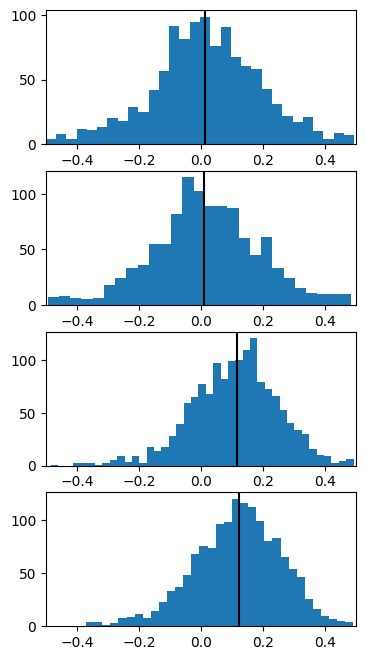

In [4]:
# plot enrichment score distributions

fig, ax = plt.subplots(4,1, figsize=(4,8))
i=0
for exp in protein_summary_all.groupby('experiment'):
    print(exp[0])
    dat = exp[1]
    ax[i].hist(dat['OPP_score'],bins=50)
    ax[i].set_xlim(-0.5,0.5)
    ax[i].axvline(dat['OPP_score'].median(),color='black')
    i+=1

In [5]:
# t_score for likeproteins in each sample
from scipy.stats import ttest_ind
from scipy.stats import ttest_1samp

df = protein_summary_all


# map condition
df['condition'] = df['experiment'].map({
    'OPP_1': 'OPP',
    'OPP_2': 'OPP',
    'DMSO_1': 'control',
    'DMSO_2': 'control'
})

results = []

for protein, group in df.groupby('proteinID'):
    
    opp = group[group['condition'] == 'OPP']['OPP_score']
    ctrl = group[group['condition'] == 'control']['OPP_score']
    
    # require at least 2 per condition
    if len(opp) >= 2 and len(ctrl) >= 2:
        t_stat, p_val = ttest_ind(opp, ctrl,alternative='greater', equal_var=False)
    else:
        t_stat, p_val = (None, None)
    
    
    results.append({
        'proteinID': protein,
        't_stat': t_stat,
        'p_value': p_val,
        'log2FC': opp.mean() - ctrl.mean()
    })

results_df = pd.DataFrame(results)


/home/lroche/miniconda3/envs/OPPproteomics/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


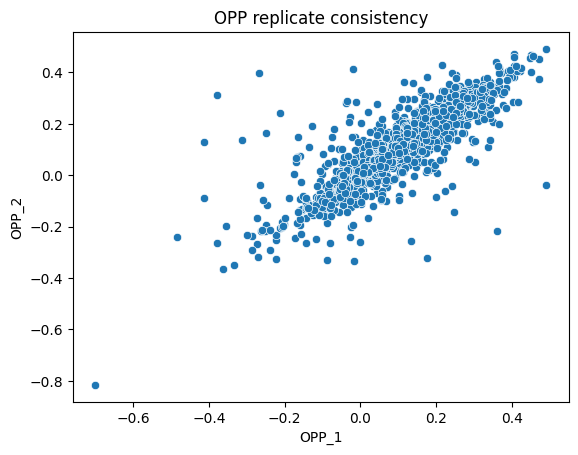

In [6]:
# replicate consistency

pivot = df.pivot_table(index='proteinID', columns='experiment', values='OPP_score')

sns.scatterplot(x=pivot['OPP_1'], y=pivot['OPP_2'])
plt.title('OPP replicate consistency')
plt.show()

# Method 2: Peptide level intensity vs position slope metric

In [51]:
import numpy as np
import pandas as pd
from scipy.stats import norm
from statsmodels.stats.multitest import multipletests

prot_col = 'proteinID' # name of column containing protein IDs
pep_col = 'Sequence' # name of column containng peptide sequence
len_col = 'Length_y' # name of column containing length of protein
pos_col = 'Mid position' # name of column containing peptide position within protein
ctrl = ('LFQ intensity DMSO_1', 'LFQ intensity DMSO_2') # tuple of columns containing control intensities
opp = ('LFQ intensity OPP_1', 'LFQ intensity OPP_2') # tuple of columns containing OPP experiment intensities



def compute_weighted_position_slopes(
    df,
    protein_col=prot_col,
    peptide_col=pep_col,
    length_col=len_col,
    position_col=pos_col,
    ctrl_cols=ctrl,
    opp_cols=opp,
    min_peptides_per_protein=3,
    pseudocount=1.0,
    shrinkage_lambda=0.25
):
    data = df.copy()

    needed_cols = [
        protein_col, peptide_col, length_col, position_col,
        *ctrl_cols, *opp_cols
    ]

    missing_cols = [c for c in needed_cols if c not in data.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    data = data[needed_cols].copy()

    intensity_cols = list(ctrl_cols) + list(opp_cols)

    # Convert numeric columns
    for col in intensity_cols + [length_col, position_col]:
        data[col] = pd.to_numeric(data[col], errors='coerce')

    # Treat zero/negative LFQ as missing
    for col in intensity_cols:
        data.loc[data[col] <= 0, col] = np.nan

    # Relative peptide position
    data['relative_position'] = data[position_col] / data[length_col]

    data.loc[
        (~np.isfinite(data['relative_position'])) |
        (data['relative_position'] < 0) |
        (data['relative_position'] > 1),
        'relative_position'
    ] = np.nan

    # Log2 transform intensities
    for col in intensity_cols:
        data[f'log2_{col}'] = np.log2(data[col] + pseudocount)

    log_ctrl_cols = [f'log2_{c}' for c in ctrl_cols]
    log_opp_cols = [f'log2_{c}' for c in opp_cols]

    # Peptide-level log2FC
    data['mean_log2_DMSO'] = data[log_ctrl_cols].mean(axis=1, skipna=True)
    data['mean_log2_OPP'] = data[log_opp_cols].mean(axis=1, skipna=True)
    data['peptide_log2_fc'] = data['mean_log2_OPP'] - data['mean_log2_DMSO']

    # Estimate peptide-level variance from replicate disagreement
    if len(ctrl_cols) == 2 and len(opp_cols) == 2:
        log_d1, log_d2 = log_ctrl_cols
        log_o1, log_o2 = log_opp_cols

        data['var_DMSO'] = (data[log_d1] - data[log_d2]) ** 2 / 2
        data['var_OPP'] = (data[log_o1] - data[log_o2]) ** 2 / 2

        data['peptide_var_raw'] = data[['var_DMSO', 'var_OPP']].mean(
            axis=1,
            skipna=True
        )
    else:
        raise ValueError("This function currently expects exactly 2 DMSO and 2 OPP replicates.")

    # Fill missing variances with global median
    global_var = data['peptide_var_raw'].median(skipna=True)

    if pd.isna(global_var) or global_var <= 0:
        global_var = 1.0

    data['peptide_var'] = data['peptide_var_raw'].fillna(global_var)

    # Shrinkage prevents huge weights from near-zero variance
    data['peptide_var_shrunk'] = data['peptide_var'] + shrinkage_lambda
    data['peptide_weight'] = 1.0 / data['peptide_var_shrunk']

    # Keep usable peptide rows
    peptide_scores = data.dropna(
        subset=[
            protein_col,
            peptide_col,
            'relative_position',
            'peptide_log2_fc',
            'peptide_weight'
        ]
    ).copy()

    def weighted_linear_fit(x, y, w):
        X = np.column_stack([np.ones(len(x)), x])
        W = np.diag(w)

        XtWX = X.T @ W @ X
        XtWy = X.T @ W @ y

        try:
            beta = np.linalg.solve(XtWX, XtWy)
        except np.linalg.LinAlgError:
            beta = np.linalg.pinv(XtWX) @ XtWy

        fitted = X @ beta
        residuals = y - fitted

        dof = max(len(y) - 2, 1)

        rss_weighted = np.sum(w * residuals**2)
        sigma2 = rss_weighted / dof

        try:
            cov_beta = sigma2 * np.linalg.inv(XtWX)
        except np.linalg.LinAlgError:
            cov_beta = sigma2 * np.linalg.pinv(XtWX)

        se_beta = np.sqrt(np.diag(cov_beta))

        intercept = beta[0]
        slope = beta[1]

        intercept_se = se_beta[0]
        slope_se = se_beta[1]

        slope_z = slope / slope_se if slope_se > 0 else np.nan
        slope_pval = 2 * norm.sf(abs(slope_z)) if np.isfinite(slope_z) else np.nan

        return {
            'position_intercept': intercept,
            'position_intercept_se': intercept_se,
            'position_slope': slope,
            'position_slope_se': slope_se,
            'position_z': slope_z,
            'position_pval': slope_pval,
            'weighted_rss': rss_weighted,
            'sigma2': sigma2
        }

    protein_rows = []

    for protein_id, group in peptide_scores.groupby(protein_col, dropna=False):
        group = group.sort_values('relative_position').copy()

        n_peptides = group[peptide_col].nunique()
        n_positions = group['relative_position'].nunique()

        if n_peptides < min_peptides_per_protein:
            continue

        if n_positions < 3:
            continue

        x = group['relative_position'].to_numpy(dtype=float)
        y = group['peptide_log2_fc'].to_numpy(dtype=float)
        w = group['peptide_weight'].to_numpy(dtype=float)

        fit = weighted_linear_fit(x, y, w)

        protein_rows.append({
            protein_col: protein_id,
            'n_peptides': n_peptides,
            'n_positions': n_positions,
            'mean_relative_position': np.mean(x),
            'median_relative_position': np.median(x),
            **fit
        })

    protein_summary = pd.DataFrame(protein_rows)

    if protein_summary.empty:
        raise ValueError(
            "No proteins could be summarised. Check missing values, positions, and peptide counts."
        )

    # FDR correction for slope p-values
    protein_summary['position_fdr'] = np.nan

    valid = protein_summary['position_pval'].notna()

    if valid.sum() > 0:
        protein_summary.loc[valid, 'position_fdr'] = multipletests(
            protein_summary.loc[valid, 'position_pval'],
            method='fdr_bh'
        )[1]

    protein_summary['position_trend'] = np.where(
        protein_summary['position_slope'] > 0,
        'Stronger toward C-terminus',
        'Stronger toward N-terminus'
    )

    protein_summary = protein_summary.sort_values(
        ['position_fdr', 'position_pval'],
        ascending=True
    ).reset_index(drop=True)

    return protein_summary, peptide_scores

In [52]:
clean_df = merged.copy()

if 'Reverse' in clean_df.columns:
    clean_df = clean_df[clean_df['Reverse'] != '+']

if 'Potential contaminant' in clean_df.columns:
    clean_df = clean_df[clean_df['Potential contaminant'] != '+']

cols = [
    'LFQ intensity DMSO_1',
    'LFQ intensity DMSO_2',
    'LFQ intensity OPP_1',
    'LFQ intensity OPP_2'
]
for col in cols:
    clean_df[col] = clean_df[col].replace(0, np.nan)

protein_results, peptide_results = compute_position_aware_protein_scores(clean_df)

In [54]:
sig = protein_results[
    (protein_results['protein_fdr'] < 0.05) &
    (protein_results['protein_log2_fc_position_aware'].abs() > 0.5)
]
sig

,proteinID,n_peptides,protein_log2_fc_position_aware,protein_se,protein_z,protein_pval,position_intercept,position_intercept_se,position_slope,position_slope_se,...,median_relative_position,n_term_fc,c_term_fc,delta_c_minus_n,model_type,protein_fdr,position_fdr,direction,position_trend,abs_log2_fc
0,A0A8L2QDW8,55,-3.912755,0.086762,-45.097541,0.000000e+00,-3.873489,0.203794,-0.089170,0.393438,...,0.456743,-3.954769,-4.322555,-0.367786,weighted_position_regression,0.000000e+00,9.075866e-01,Higher in DMSO,Stronger toward N-terminus,3.912755
1,A0A8I6AQ31,25,-4.764493,0.127521,-37.362404,1.594643e-305,-4.993379,0.293395,0.395278,0.463503,...,0.514873,-5.206633,-4.622475,0.584158,weighted_position_regression,6.665608e-303,6.084836e-01,Higher in DMSO,Stronger toward C-terminus,4.764493
2,M0R9X8,184,-1.311820,0.043009,-30.500827,2.540897e-204,-1.329771,0.119608,0.038115,0.217480,...,0.440755,-1.352797,-1.161573,0.191224,weighted_position_regression,7.080633e-202,9.310376e-01,Higher in DMSO,Stronger toward C-terminus,1.311820
3,A0A8I5YBZ6,33,-3.314954,0.115400,-28.725675,1.823794e-181,-3.998151,0.245195,1.627911,0.517369,...,0.375848,-3.661300,-2.497451,1.163848,weighted_position_regression,3.811730e-179,9.461029e-03,Higher in DMSO,Stronger toward C-terminus,3.314954
4,A0A0G2K1Y8,108,-1.376287,0.056353,-24.422806,9.791632e-132,0.007175,0.118406,-3.391877,0.241470,...,0.337670,-0.602853,-2.689967,-2.087114,weighted_position_regression,1.637161e-129,4.491619e-43,Higher in DMSO,Stronger toward N-terminus,1.376287
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
394,A0A8L2R514,4,-0.653495,0.271569,-2.406362,1.611227e-02,-1.870026,1.618922,3.327252,4.099758,...,0.309983,-0.713631,NaN,NaN,weighted_position_regression,3.410090e-02,6.315991e-01,Higher in DMSO,Stronger toward C-terminus,0.653495
395,A0A0G2JXM1,5,0.585414,0.246189,2.377899,1.741160e-02,1.784659,0.659183,-1.914796,0.938729,...,0.770386,1.681509,0.270686,-1.410823,weighted_position_regression,3.675782e-02,1.285781e-01,Higher in OPP,Stronger toward N-terminus,0.585414
400,Q9QUR2,6,0.526643,0.227470,2.315220,2.060088e-02,0.063034,0.374934,1.510535,0.909732,...,0.244647,0.124779,0.941391,0.816613,weighted_position_regression,4.294847e-02,2.360061e-01,Higher in OPP,Stronger toward C-terminus,0.526643
405,A0A8I6GKY5,3,0.668693,0.292317,2.287563,2.216296e-02,0.922769,0.020545,-0.589158,0.045036,...,0.529279,0.793101,NaN,NaN,weighted_position_regression,4.552393e-02,2.051252e-37,Higher in OPP,Stronger toward N-terminus,0.668693


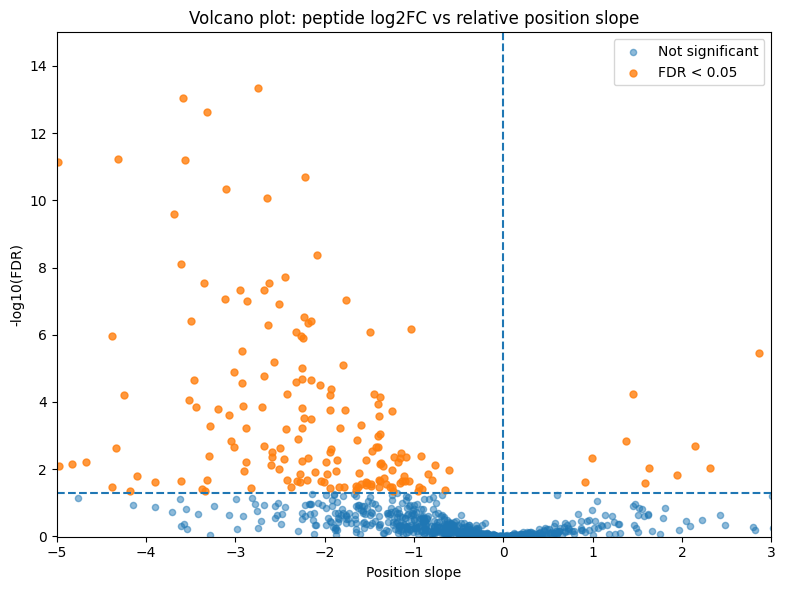

In [55]:
import numpy as np
import matplotlib.pyplot as plt

def plot_position_slope_volcano(
    protein_slopes,
    slope_col='position_slope',
    fdr_col='position_fdr',
    protein_col='proteinID',
    fdr_cutoff=0.05,
    slope_cutoff=0.0,
    top_n_labels=0
):
    df = protein_slopes.copy()

    df = df.dropna(subset=[slope_col, fdr_col])
    df[fdr_col] = df[fdr_col].clip(lower=1e-300)
    df['minus_log10_fdr'] = -np.log10(df[fdr_col])

    df['significant'] = (
        (df[fdr_col] < fdr_cutoff) &
        (df[slope_col].abs() > slope_cutoff)
    )

    plt.figure(figsize=(8, 6))

    plt.scatter(
        df.loc[~df['significant'], slope_col],
        df.loc[~df['significant'], 'minus_log10_fdr'],
        alpha=0.5,
        s=20,
        label='Not significant'
    )

    plt.scatter(
        df.loc[df['significant'], slope_col],
        df.loc[df['significant'], 'minus_log10_fdr'],
        alpha=0.8,
        s=25,
        label=f'FDR < {fdr_cutoff}'
    )

    plt.axhline(-np.log10(fdr_cutoff), linestyle='--')
    plt.axvline(0, linestyle='--')

    top_hits = df[df['significant']].sort_values(fdr_col).head(top_n_labels)

    for _, row in top_hits.iterrows():
        plt.text(
            row[slope_col],
            row['minus_log10_fdr'],
            str(row[protein_col]),
            fontsize=8
        )

    plt.xlabel('Position slope')
    plt.ylabel('-log10(FDR)')
    plt.title('Volcano plot: peptide log2FC vs relative position slope')
    plt.legend()
    plt.tight_layout()
    plt.xlim(-5,3)
    plt.ylim(-0.01, 15)
    plt.savefig('results/protein_log2fc_slope_volcano.png')
    plt.show()
plot_position_slope_volcano(protein_results)

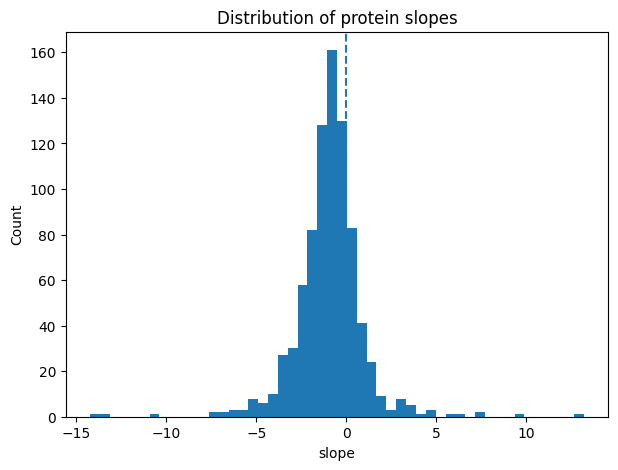

In [56]:
plt.figure(figsize=(7,5))

plt.hist(
    protein_results['position_slope'].dropna(),
    bins=50
)

plt.axvline(0, linestyle='--')

plt.xlabel('slope')
plt.ylabel('Count')
plt.title('Distribution of protein slopes')
plt.savefig('results/slope_distribution.png')
plt.show()

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_protein_slope_example(
    df,
    protein_id='P50137',
    protein_col='proteinID',
    peptide_col='Sequence',
    length_col='Length_y',
    position_col='Mid position',
    ctrl_cols=('LFQ intensity DMSO_1', 'LFQ intensity DMSO_2'),
    opp_cols=('LFQ intensity OPP_1', 'LFQ intensity OPP_2'),
    pseudocount=1.0,
    shrinkage_lambda=0.25
):
    data = df.copy()

    cols = list(ctrl_cols) + list(opp_cols)
    needed = [protein_col, peptide_col, length_col, position_col, *cols]
    missing = [c for c in needed if c not in data.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    data = data[needed].copy()

    for col in cols + [length_col, position_col]:
        data[col] = pd.to_numeric(data[col], errors='coerce')

    # MaxQuant missing values
    for col in cols:
        data[col] = data[col].replace(0, np.nan)

    # keep protein
    sub = data[data[protein_col] == protein_id].copy()
    if sub.empty:
        raise ValueError(f"No rows found for protein {protein_id}")

    # relative position
    sub['relative_position'] = sub[position_col] / sub[length_col]
    sub.loc[
        (~np.isfinite(sub['relative_position'])) |
        (sub['relative_position'] < 0) |
        (sub['relative_position'] > 1),
        'relative_position'
    ] = np.nan

    # log2 intensities
    for col in cols:
        sub[f'log2_{col}'] = np.log2(sub[col] + pseudocount)

    log_d1, log_d2 = [f'log2_{c}' for c in ctrl_cols]
    log_o1, log_o2 = [f'log2_{c}' for c in opp_cols]

    # peptide log2FC
    sub['mean_log2_DMSO'] = sub[[log_d1, log_d2]].mean(axis=1, skipna=True)
    sub['mean_log2_OPP'] = sub[[log_o1, log_o2]].mean(axis=1, skipna=True)
    sub['peptide_log2_fc'] = sub['mean_log2_OPP'] - sub['mean_log2_DMSO']

    # within-condition variance and weights
    sub['var_DMSO'] = (sub[log_d1] - sub[log_d2]) ** 2 / 2
    sub['var_OPP'] = (sub[log_o1] - sub[log_o2]) ** 2 / 2
    sub['peptide_var_raw'] = sub[['var_DMSO', 'var_OPP']].mean(axis=1, skipna=True)

    global_var = sub['peptide_var_raw'].median(skipna=True)
    if pd.isna(global_var):
        global_var = 1.0

    sub['peptide_var'] = sub['peptide_var_raw'].fillna(global_var)
    sub['peptide_weight'] = 1.0 / (sub['peptide_var'] + shrinkage_lambda)

    # keep usable peptides
    sub = sub.dropna(subset=['relative_position', 'peptide_log2_fc']).copy()
    if len(sub) < 2:
        raise ValueError(f"Not enough usable peptides for protein {protein_id}")

    x = sub['relative_position'].to_numpy(float)
    y = sub['peptide_log2_fc'].to_numpy(float)
    w = sub['peptide_weight'].to_numpy(float)

    # weighted regression
    X = np.column_stack([np.ones(len(x)), x])
    W = np.diag(w)

    XtWX = X.T @ W @ X
    XtWy = X.T @ W @ y
    beta = np.linalg.pinv(XtWX) @ XtWy
    intercept, slope = beta

    xx = np.linspace(0, 1, 200)
    yy = intercept + slope * xx

    # point sizes reflect weights
    point_sizes = 40 + 160 * (w / np.max(w))

    plt.figure(figsize=(6, 4))
    plt.scatter(x, y, s=point_sizes, alpha=0.8)
    plt.plot(xx, yy, linewidth=2)
    plt.axhline(0, linestyle='--')
    plt.xlabel('Relative peptide position')
    plt.ylabel('Peptide log2 fold-change (OPP - DMSO)')
    plt.title(f'{protein_id}: peptide-level enrichment and weighted slope')
    plt.savefig('results/example_protein_slope_calculation.png')
    plt.tight_layout()
    plt.show()

    print(f"Protein: {protein_id}")
    print(f"Peptides used: {len(sub)}")
    print(f"Weighted slope: {slope:.4f}")
    print(f"Intercept: {intercept:.4f}")
    return sub, intercept, slope

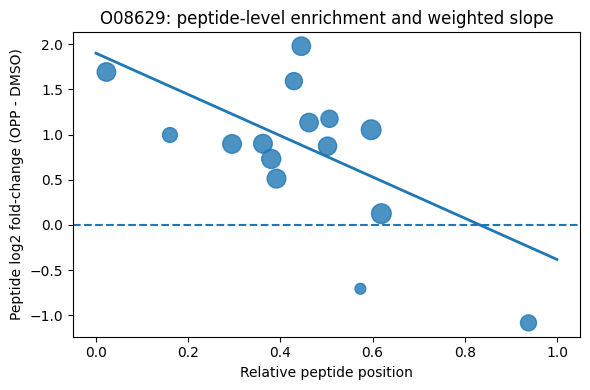

Protein: O08629
Peptides used: 15
Weighted slope: -2.2822
Intercept: 1.9004


In [58]:
sub_p50137, intercept, slope = plot_protein_slope_example(clean_df, protein_id='O08629')

In [59]:
sig.to_csv('results/significant_protein_slopes.txt',sep='\t')